# Работа с табличными данными

## 1. Pandas

**Pandas** — это одна из самых популярных библиотек Python для работы с табличными данными. Она предоставляет удобные 
структуры данных:
* **Series** — одномерный массив с индексами, похожий на колонку в таблице;
* **DataFrame** — двумерная таблица, где каждая колонка может иметь свой тип данных.

![pandas](../misc/images/pandas.jpeg)

С помощью Pandas можно: фильтровать строки и столбцы, группировать данные, агрегировать показатели, объединять таблицы, 
работать с пропущенными значениями и строить простые визуализации. Владение Pandas — базовый и необходимый навык для 
проведения EDA.

In [11]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Задание 1.1. Загрузка данных
1. Пройди по ссылке на хранилище с датасетом [2025 Kaggle Machine Learning & Data Science Survey](https://disk.360.yandex.ru/d/ATLDXjTVorMf3Q).
3. Скачай CSV-файлы с данными и сохрани их в папку `datasets`.
4. С помощью библиотеки `pandas` загрузи:
   * таблицу с выбором ответов (multiple choice) в переменную `multiple`,
   * таблицу со свободными ответами (free form) `freeform`.
5. Выведи размеры каждой таблицы.
   
> **Важно:** загружать датасеты на Git не нужно.

In [12]:
link1 = "C://Users/User/Desktop/ad3/AI_Data_Analytics.Project_3.ID_1577559-1/datasets/multiple_choice_responses.csv"
link2 = "C://Users/User/Desktop/ad3/AI_Data_Analytics.Project_3.ID_1577559-1/datasets/freeform_responses.csv"

multipe = pd.read_csv(link1)
freefrom = pd.read_csv(link2)



print(multipe.shape)
print(freefrom.shape)

C:\Users\User\AppData\Local\Temp\ipykernel_22316\2446386378.py:4: DtypeWarning: Columns (0: Time from Start to Finish (seconds), 1: Q1_OTHER_TEXT, 2: Q6_OTHER_TEXT, 3: Q7_OTHER_TEXT, 4: Q11_OTHER_TEXT, 5: Q12_Part_1_TEXT, 6: Q12_Part_2_TEXT, 7: Q12_Part_3_TEXT, 8: Q12_Part_4_TEXT, 9: Q12_Part_5_TEXT, 10: Q12_OTHER_TEXT, 11: Q13_Part_14, 12: Q13_OTHER_TEXT, 13: Q14_Part_10, 14: Q14_OTHER_TEXT, 15: Q15_OTHER_TEXT, 16: Q16_Part_17, 17: Q16_OTHER_TEXT, 18: Q17_OTHER_TEXT, 19: Q18_OTHER_TEXT, 20: Q19_Part_18, 21: Q19_OTHER_TEXT, 22: Q20_OTHER_TEXT, 23: Q21_Part_12, 24: Q21_OTHER_TEXT, 25: Q22_OTHER_TEXT, 26: Q27_Part_19, 27: Q27_OTHER_TEXT, 28: Q28_Part_7, 29: Q28_Part_22, 30: Q28_Part_24, 31: Q28_Part_42, 32: Q28_OTHER_TEXT, 33: Q29_Part_16, 34: Q29_Part_24, 35: Q29_Part_25, 36: Q29_Part_27, 37: Q29_OTHER_TEXT, 38: Q30_Part_23, 39: Q30_Part_24, 40: Q30_OTHER_TEXT, 41: Q31_OTHER_TEXT, 42: Q32_OTHER_TEXT, 43: Q33_OTHER_TEXT, 44: Q34_Part_1, 45: Q34_Part_2, 46: Q34_Part_3, 47: Q34_Part_4, 48:

(23860, 394)
(23860, 35)


C:\Users\User\AppData\Local\Temp\ipykernel_22316\2446386378.py:5: DtypeWarning: Columns (0: Q34_OTHER_TEXT) have mixed types. Specify dtype option on import or set low_memory=False.
  freefrom = pd.read_csv(link2)


### Задание 1.2. Словарь вопросов
В таблицах `freeform` и `multiple` первая строка содержит текстовые формулировки вопросов (например: *'What is your gender? — Selected Choice'*, *'What is your age (# years)?'* и т. д.), а сами данные начинаются со второй строки.

1. Создай структуру `name2question`, которая для каждой колонки содержит словарь с ключами `question` и `type`. В ключе `question` хранится текст вопроса, а в ключе `type` — тип таблицы, из которой пришел вопрос: `'multiple'`, `'freeform'` или `'both'` (если колонка есть в обеих таблицах).
```
name2question['Q1']
{'question': 'What is your gender? - Selected Choice', 'type': 'multiple'}
```

2. Выведи значение для вопроса `Q1_OTHER_TEXT` из структуры `name2question`.
3. Удали первые строки из таблиц `freeform` и `multiple`.
4. Выведи размерности таблиц `freeform` и `multiple`.

In [13]:
name2question = dict()
m = multipe.iloc[0]
f = freefrom.iloc[0]

for col in multipe.columns:
    name2question[col] = {
        "question": m[col],
        "type": "multipe"
    }


for col in freefrom.columns:
    if col in name2question:
        name2question[col]["type"] = "both"
    else:
        name2question[col] = {
            "question": f[col],
            "type": "freefrom"
    }



name2question["Q1_OTHER_TEXT"]

multipe = multipe.drop(0)
freefrom = freefrom.drop(0)

print(multipe.shape)
print(freefrom.shape)

(23859, 394)
(23859, 35)


In [14]:
multipe.head()

,Time from Start to Finish (seconds),Q1,Q1_OTHER_TEXT,Q2,Q3,Q4,Q5,Q6,Q6_OTHER_TEXT,Q7,...,Q49_OTHER_TEXT,Q50_Part_1,Q50_Part_2,Q50_Part_3,Q50_Part_4,Q50_Part_5,Q50_Part_6,Q50_Part_7,Q50_Part_8,Q50_OTHER_TEXT
1,710,Female,-1,45-49,United States of America,Doctoral degree,Other,Consultant,-1,Other,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2,434,Male,-1,30-34,Indonesia,Bachelor’s degree,Engineering (non-computer focused),Other,0,Manufacturing/Fabrication,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
3,718,Female,-1,30-34,United States of America,Master’s degree,"Computer science (software engineering, etc.)",Data Scientist,-1,I am a student,...,-1,NaN,Too time-consuming,NaN,NaN,NaN,NaN,NaN,NaN,-1
4,621,Male,-1,35-39,United States of America,Master’s degree,"Social sciences (anthropology, psychology, soc...",Not employed,-1,NaN,...,-1,NaN,NaN,Requires too much technical knowledge,NaN,Not enough incentives to share my work,NaN,NaN,NaN,-1
5,731,Male,-1,22-24,India,Master’s degree,Mathematics or statistics,Data Analyst,-1,I am a student,...,-1,NaN,Too time-consuming,NaN,NaN,Not enough incentives to share my work,NaN,NaN,NaN,-1


### Задание 1.3. Анализ общих колонок

В таблице `multiple` некоторые колонки содержат числовые коды ответов. Если значение отлично от `-1`, это означает, что респондент выбрал свой вариант ответа, и в таблице `freeform` для той же строки (с тем же индексом) должно присутствовать соответствующее текстовое значение в свободной форме.

Проверить возможность корректного объединения таблиц `multiple` и `freeform`.

1. Определи общие колонки:
   - Найди все колонки, которые присутствуют одновременно в таблицах `multiple` и `freeform`.
   - Выведи их количество.

2. Проведи анализ общих колонок:
   - Выбери 2–3 общие колонки для детального изучения (например, `Q1_OTHER_TEXT`, `Q6_OTHER_TEXT`).
   - Для каждой выбранной колонки:
     - Выведи частоты значений в таблице `multiple` (количество значений, отличных от `-1`).
     - Выведи частоты значений в таблице `freeform` (количество непустых текстовых значений).
     - Найди индексы строк, где в таблице `multiple` значение отлично от `-1`.
     - Найди индексы строк, где в таблице `freeform` присутствуют текстовые значения.
     - Сравни эти два набора индексов.

3. Напиши свои выводы по результатам анализа:
   - Можно ли корректно объединить эти две таблицы по индексам строк?
   - Если нет, приведи конкретные примеры, демонстрирующие проблему (выведи соответствующие строки из обеих таблиц).

In [15]:
common_colums = pd.merge(freefrom, multipe)

print(common_colums.shape[1])

a1 = multipe["Q1_OTHER_TEXT"]
a2 = freefrom["Q1_OTHER_TEXT"]

b1 = multipe["Q6_OTHER_TEXT"]
b2 = freefrom["Q6_OTHER_TEXT"]

test1_1 = (multipe["Q1_OTHER_TEXT"] != -1).sum()
test1_2 = (multipe["Q6_OTHER_TEXT"] != -1).sum()

print(f"test 1: {test1_1}, {test1_2}")

test2_1 = (freefrom["Q1_OTHER_TEXT"].notna()).sum()
test2_2 = (freefrom["Q6_OTHER_TEXT"].notna()).sum()

print(f"test 2: {test2_1}, {test2_2}")

test3_1 = multipe[multipe["Q1_OTHER_TEXT"] != -1].index.to_list()
test3_2 = multipe[multipe["Q6_OTHER_TEXT"] != -1].index.to_list()

print(f"test 3_1: {test3_1}")
print(f"test 3_2: {test3_2}")

test4_1 = freefrom[freefrom["Q1_OTHER_TEXT"].apply(lambda x: isinstance(x, str) and str(x).strip() != '')].index.to_list()
test4_2 = freefrom[freefrom["Q1_OTHER_TEXT"].apply(lambda x: isinstance(x, str) and str(x).strip() != '')].index.to_list()

print(f"test 4_1: {test4_1}")
print(f"test 4_2: {test4_2}")

394
test 1: 2121, 3256
test 2: 79, 1322
test 3_1: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 21

***Результаты анализа:***первый набор нельзя объединить, а второй можно

In [16]:
for i in test3_1:
    if i not in test3_2:
        print(i)

2633
2872
3209
3212
3513
3793
4212
4219
4253
4460
4581
4913
5194
6487
6517
6605
6710
7028
7098
7113
7183
7414
7451
7581
9078
9268
9305
9538
9748
9919
10039
10232
10309
10392
10407
11135
11516
11673
11812
12260
12353
12965
13021
15016
15082
15314
15454
15682
15903
16329
16599
16613
16895
16904
17083
17172
17928
18334
18357
19384
19421
20576
20946
21086
21716
22807
23483


### Задание 1.4. Объединение таблиц
В предыдущем задании мы выяснили, что таблицы `multiple` и `freeform` нельзя просто объединить по номерам строк — данные не совпадают. Но мы можем попробовать восстановить связи между числовыми кодами из `multiple` и текстовыми ответами из `freeform`.

_Идея:_ если какое-то текстовое значение встречается в `freeform` определенное количество раз, и в `multiple` есть числовой код, который встречается такое же количество раз, причем эта частота уникальна (встречается только один раз в каждой таблице), то, скорее всего, это одно и то же значение.

Что нужно сделать:
1. Создай копию таблицы `multiple` и сохрани ее в переменную `responses`.
2. Для каждой общей колонки:
   - Посчитай, сколько раз встречается каждое значение в `multiple` (не считай `-1` и пустые значения).
   - Посчитай, сколько раз встречается каждое значение в `freeform` (не считай пустые строки и пустые значения).
   - Найди пары, где:
     * Частота совпадает (например, и код, и текст встречаются по 7 раз).
     * Эта частота уникальна (встречается только один раз в каждой таблице).
   - Выполни замену значений в колонке таблицы `responses`:
     * Значения, которые были равны `-1`, оставь без изменений (`-1`).
     * Найденные числовые коды (для которых удалось найти соответствующее текстовое значение) замени на соответствующие текстовые значения из `freeform`.
     * Для всех остальных числовых кодов (которые не удалось сопоставить) замени на `-2`.
3. Подсчитай и выведи:
   - Средний процент текстовых значений из `freeform`, которые удалось успешно сопоставить с числовыми кодами из `multiple`, по всем колонкам **(в процентах)**.
   - Название колонки, для которой получилось сопоставить больше всего значений.


In [17]:
from collections import defaultdict

responses = multipe.copy()

count_multipe = defaultdict(lambda: defaultdict(int))
count_freefrom = defaultdict(lambda: defaultdict(int))


for col in multipe.columns:
    for val in multipe[col]:
        if val != -1 and val != '' and pd.notna(val):
            count_multipe[col][val] += 1


for col in freefrom.columns:
    for val in freefrom[col]:
        if pd.notna(val) and val != '':
            count_freefrom[col][val] += 1


print(count_freefrom)
print(count_multipe)

defaultdict(<function <lambda> at 0x000001A0D66958A0>, {'Q11_OTHER_TEXT': defaultdict(<class 'int'>, {'Trying to find what field of research could be machine learnable ': 1, 'I’m a student. Don’t ask these questions please': 1, 'Student': 46, 'quality analyst': 1, 'All private work': 1, 'Work with statistics staff to build a simulation model': 1, 'I stop working for my masters': 1, 'I am a student': 49, 'Data Collection': 1, 'Student studying machine learning': 2, 'Not yet started': 1, "I'm a undergrad student": 1, 'Teaching and training ': 1, 'Build data visualiztions/dashboards': 1, 'Caca': 1, 'Do Basic Data Analysis & Visualisation on Tableau ; Implementation & actual profit is not recorded.': 1, 'Software Development': 2, 'Education and Training for ML': 1, 'Creating courses and books for machine learning education': 1, 'Building a recommendation engine to put in production': 1, 'Digital marketing': 1, 'Regression Modeling ': 1, 'Erp development': 1, 'write papers in robotics, teac

In [18]:
check_dict = defaultdict(lambda: defaultdict(list))

# Создаем копии ключей для итерации
for col in list(count_freefrom.keys()):
    if col in count_multipe:  # Проверяем наличие ключа в обоих словарях
        # Создаем списки ключей для безопасной итерации
        free_keys = list(count_freefrom[col].keys())
        multi_keys = list(count_multipe[col].keys())
        for key in free_keys:
            for key1 in multi_keys:
                # Проверяем, что значения еще не были обработаны
                if (count_freefrom[col][key] == count_multipe[col][key1] and 
                    count_freefrom[col][key] != -1):
                    check_dict[col][key1] = [key, count_freefrom[col][key]]
                    count_freefrom[col][key] = count_multipe[col][key1] = -1

print(check_dict)

defaultdict(<function <lambda> at 0x000001A0D694F420>, {'Q11_OTHER_TEXT': defaultdict(<class 'list'>, {'0': ['Trying to find what field of research could be machine learnable ', 1], '1': ['I’m a student. Don’t ask these questions please', 1], '2': ['quality analyst', 1], '3': ['All private work', 1], '4': ['Work with statistics staff to build a simulation model', 1], '6': ['I stop working for my masters', 1], '7': ['Data Collection', 1], '31': ['Student studying machine learning', 2], '8': ['Not yet started', 1], '9': ["I'm a undergrad student", 1], '10': ['Teaching and training ', 1], '11': ['Build data visualiztions/dashboards', 1], '12': ['Caca', 1], '13': ['Do Basic Data Analysis & Visualisation on Tableau ; Implementation & actual profit is not recorded.', 1], 72: ['Software Development', 2], '14': ['Education and Training for ML', 1], '15': ['Creating courses and books for machine learning education', 1], '17': ['Building a recommendation engine to put in production', 1], '18': [

In [19]:
find = defaultdict(int)
total = defaultdict(int)

for col in responses.columns:
    # Проверяем, есть ли столбец в check_dict
    if col in check_dict:
        for idx in responses.index:  # Лучше итерироваться по индексам DataFrame
            value = responses.loc[idx, col]
            
            if pd.isna(value) or value == '':
                continue
                
            total[col] += 1

            if value in check_dict[col]:
                find[col] += 1
                responses.loc[idx, col] = check_dict[col][value][0]
            else:
                if responses.loc[idx, col] == -1:
                    responses.loc[idx, col] = -2

print(responses["Q12_Part_2_TEXT"].value_counts())

Q12_Part_2_TEXT
-2     20500
-1      1912
16       194
4        139
8        138
       ...  
499        1
500        1
501        1
502        1
503        1
Name: count, Length: 533, dtype: int64


In [20]:
procents = dict()

for key in find:
    procents[key] = round((find[key]/total[key]) * 100)

print(procents)

p_df = pd.DataFrame.from_dict(procents, orient='index', columns=['Процент'])

max_row = p_df.loc[p_df['Процент'].idxmax()]
print(max_row)

{'Q1_OTHER_TEXT': 0, 'Q6_OTHER_TEXT': 5, 'Q7_OTHER_TEXT': 3, 'Q11_OTHER_TEXT': 2, 'Q12_Part_1_TEXT': 6, 'Q12_Part_2_TEXT': 3, 'Q12_Part_3_TEXT': 3, 'Q12_Part_4_TEXT': 19, 'Q12_Part_5_TEXT': 3, 'Q12_OTHER_TEXT': 5, 'Q13_OTHER_TEXT': 3, 'Q14_OTHER_TEXT': 2, 'Q15_OTHER_TEXT': 2, 'Q16_OTHER_TEXT': 2, 'Q17_OTHER_TEXT': 0, 'Q18_OTHER_TEXT': 1, 'Q19_OTHER_TEXT': 2, 'Q20_OTHER_TEXT': 0, 'Q21_OTHER_TEXT': 2, 'Q22_OTHER_TEXT': 0, 'Q27_OTHER_TEXT': 1, 'Q28_OTHER_TEXT': 1, 'Q29_OTHER_TEXT': 1, 'Q30_OTHER_TEXT': 1, 'Q31_OTHER_TEXT': 1, 'Q32_OTHER_TEXT': 0, 'Q33_OTHER_TEXT': 1, 'Q34_OTHER_TEXT': 1, 'Q35_OTHER_TEXT': 2, 'Q36_OTHER_TEXT': 4, 'Q37_OTHER_TEXT': 1, 'Q38_OTHER_TEXT': 5, 'Q42_OTHER_TEXT': 1, 'Q49_OTHER_TEXT': 1, 'Q50_OTHER_TEXT': 2}
Процент    19
Name: Q12_Part_4_TEXT, dtype: int64


### Задание 1.5. Анализ пропусков
Мы объединили наши данные ответов в сводной форме. Давай проанализируем, насколько респондентам хватало предложенных вариантов ответа на вопросы. В опросе есть вопросы, где респонденты могли выбрать вариант из предложенных, а также написать свой ответ в свободной форме. Если респондент часто предпочитал сам давать ответы, это может указывать на то, что предложенные варианты были недостаточно полными.

1. Найди все **вопросы**, в которых встречаются колонки со свободным ответом. Исключи вопрос `Q12` — в нем свободный ответ встречается несколько раз. Выведи количество таких вопросов.

2. Среди этих вопросов найди:

   - Вопрос, на который респонденты чаще всего не выбирали ответа из предложенных.
   - Вопрос, на который респонденты всегда выбирали ответ из предложенного.
   - Вопрос, на который респонденты чаще всего писали свободный ответ.

In [21]:
for col in responses.columns:
    if 'Q12' in col:
        responses = responses.drop(col, axis=1)

In [22]:
print(len(responses.columns))

388


In [23]:
responses.head()

,Time from Start to Finish (seconds),Q1,Q1_OTHER_TEXT,Q2,Q3,Q4,Q5,Q6,Q6_OTHER_TEXT,Q7,...,Q49_OTHER_TEXT,Q50_Part_1,Q50_Part_2,Q50_Part_3,Q50_Part_4,Q50_Part_5,Q50_Part_6,Q50_Part_7,Q50_Part_8,Q50_OTHER_TEXT
1,710,Female,-1,45-49,United States of America,Doctoral degree,Other,Consultant,-1,Other,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2,434,Male,-1,30-34,Indonesia,Bachelor’s degree,Engineering (non-computer focused),Other,Systems Analyst,Manufacturing/Fabrication,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
3,718,Female,-1,30-34,United States of America,Master’s degree,"Computer science (software engineering, etc.)",Data Scientist,-1,I am a student,...,-1,NaN,Too time-consuming,NaN,NaN,NaN,NaN,NaN,NaN,-1
4,621,Male,-1,35-39,United States of America,Master’s degree,"Social sciences (anthropology, psychology, soc...",Not employed,-1,NaN,...,-1,NaN,NaN,Requires too much technical knowledge,NaN,Not enough incentives to share my work,NaN,NaN,NaN,-1
5,731,Male,-1,22-24,India,Master’s degree,Mathematics or statistics,Data Analyst,-1,I am a student,...,-1,NaN,Too time-consuming,NaN,NaN,Not enough incentives to share my work,NaN,NaN,NaN,-1


In [24]:
check = defaultdict(int)

for col in responses.columns:
    for val in responses[col]:
        if isinstance(val, str):
            check[col] += 1

print(check)

defaultdict(<class 'int'>, {'Time from Start to Finish (seconds)': 2047, 'Q1': 23859, 'Q1_OTHER_TEXT': 2119, 'Q2': 23859, 'Q3': 23859, 'Q4': 23438, 'Q5': 22947, 'Q6': 22900, 'Q6_OTHER_TEXT': 3046, 'Q7': 21685, 'Q7_OTHER_TEXT': 2752, 'Q8': 21101, 'Q9': 20185, 'Q10': 20669, 'Q11_Part_1': 9532, 'Q11_Part_2': 5481, 'Q11_Part_3': 5233, 'Q11_Part_4': 7233, 'Q11_Part_5': 4934, 'Q11_Part_6': 3471, 'Q11_Part_7': 1192, 'Q11_OTHER_TEXT': 2404, 'Q13_Part_1': 14010, 'Q13_Part_2': 8503, 'Q13_Part_3': 7060, 'Q13_Part_4': 5082, 'Q13_Part_5': 127, 'Q13_Part_6': 3906, 'Q13_Part_7': 5671, 'Q13_Part_8': 5111, 'Q13_Part_9': 7831, 'Q13_Part_10': 5985, 'Q13_Part_11': 4240, 'Q13_Part_12': 3456, 'Q13_Part_13': 5339, 'Q13_Part_15': 1257, 'Q13_OTHER_TEXT': 2624, 'Q14_Part_1': 6042, 'Q14_Part_2': 3532, 'Q14_Part_3': 1304, 'Q14_Part_4': 119, 'Q14_Part_5': 1307, 'Q14_Part_6': 480, 'Q14_Part_7': 361, 'Q14_Part_8': 138, 'Q14_Part_9': 4916, 'Q14_Part_11': 690, 'Q14_OTHER_TEXT': 2420, 'Q15_Part_1': 4783, 'Q15_Part_2': 

In [25]:
min_pair = min(check.items(), key=lambda x: x[1])
max_pair = max(check.items(), key=lambda x: x[1])

full_pair = []

for col in responses.columns:
    count = 0
    for val in responses[col]:
        if isinstance(val, str):
            count += 1
    if count == len(responses):
        full_pair = [col]



print(min_pair)
print(full_pair)
print(max_pair)

('Q28_Part_22', 17)
['Q3']
('Q1', 23859)


### Задание 1.6. Очистка респондентов

В данных есть информация о времени заполнения опроса. Логично предположить, что, если респондент отвечал **слишком быстро** или, наоборот, **слишком долго**, такие ответы могут быть недостоверными. Для очистки данных воспользуемся методом выявления выбросов на основе **box plot**.

**Box plot (ящик с усами)** — это способ визуализации распределения данных. Внутри прямоугольника (ящика) находятся значения от 1-го до 3-го квартиля (Q1 и Q3), линия внутри — это медиана. «Усы» обычно определяются через **интерквартильный размах (IQR)**, который равен:

$$IQR = Q3 - Q1$$
Значения ниже $Q1 - 1.5 \times IQR$ и выше $Q3 + 1.5 \times IQR$ считаются выбросами.

<center><img src="../misc/images/box-plot.png" alt="analytics" width="600" height="400">

1. Построй box plot для времени заполнения опроса. Ограничь ось **X** от 0 до 5000 секунд.
2. Рассчитай интерквартильный размах (IQR).
3. Выведи нижнюю и верхнюю границы интервала для выявления выбросов.
4. Так как нижняя граница получилась отрицательной, будем априорно считать минимальное адекватное время заполнения равным **2 минутам (120 секундам)**.
5. Отфильтруй DataFrame, оставив только респондентов с временем заполнения от 120 секунд до верхней границы.
6. Выведи размерность очищенного датасета.

In [26]:
import matplotlib.pyplot as plt

time =[int(val) for val in responses["Time from Start to Finish (seconds)"]]
time = list(sorted(time))

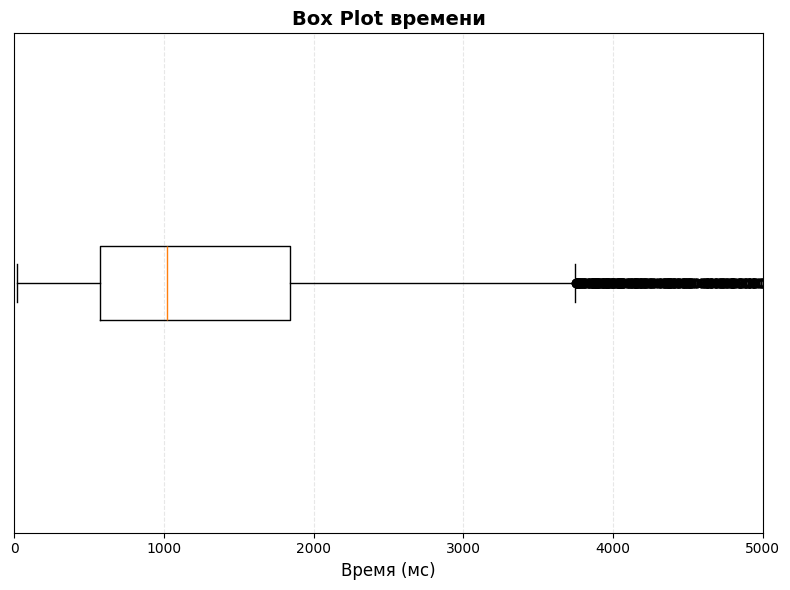

In [27]:
import matplotlib.pyplot as plt

# Предполагаем, что у вас есть переменная time с данными
# time = [ваши данные]

plt.figure(figsize=(8, 6))

# Горизонтальный box plot (поворот осей)
plt.boxplot(time, vert=False)  # vert=False для горизонтальной ориентации

plt.title('Box Plot времени', fontsize=14, fontweight='bold')
plt.xlabel('Время (мс)', fontsize=12)  # Теперь по горизонтальной оси время
plt.ylabel('')  # Убираем подпись по Y, так как только одна группа
plt.grid(True, alpha=0.3, linestyle='--')

# Ограничиваем диапазон по оси X от 0 до 5000
plt.xlim(0, 5000)

# Убираем метку по оси Y (так как только одна группа)
plt.yticks([])

plt.tight_layout()
plt.show()

In [28]:
Q1 = time[round(len(time) * 0.25)]
Q3 = time[round(len(time) * 0.75)]

IQR = Q3 - Q1

out_min = Q1 - 1.5 * IQR
out_max = Q3 + 1.5 * IQR

print(f"out_min: {out_min}")
print(f"out_max: {out_max}")

out_min: -1338.0
out_max: 3750.0


In [29]:
out_min = 120

In [30]:
responses["Time from Start to Finish (seconds)"] = pd.to_numeric(
    responses["Time from Start to Finish (seconds)"], 
    errors='coerce'  # преобразует нечисловые значения в NaN
)

# Теперь создаем условие
condition = (responses["Time from Start to Finish (seconds)"] < out_min) | \
            (responses["Time from Start to Finish (seconds)"] > out_max)

# Удаляем строки, удовлетворяющие условию
responses = responses.drop(responses[condition].index)

In [31]:
responses.shape

(18719, 388)

### Задание 1.7. Второй язык
1. Проанализируй, какие языки программирования чаще всего используют респонденты в каждой профессии. Используй `groupby` и посмотри список языков программирования внутри каждой группы.
2. Для роли `Statistician` назови самый популярный язык.
3. Для роли `Student` укажи самый непопулярный язык.
4. Для роли `Data Engineer` найди второй по популярности язык.
5. Для роли `Data Scientist` определи пятый по популярности язык.


In [32]:
for col in responses.columns:
    print(responses[col].value_counts())

Time from Start to Finish (seconds)
142     31
156     29
134     27
131     27
935     26
        ..
3542     1
2287     1
2294     1
3669     1
3629     1
Name: count, Length: 2942, dtype: int64
Q1
Male                       15262
Female                      3152
Prefer not to say            247
Prefer to self-describe       58
Name: count, dtype: int64
Q1_OTHER_TEXT
-2                                                                                                                                                                                       16780
-1                                                                                                                                                                                        1881
non-binary                                                                                                                                                                                   4
Non-binary                                             

In [33]:
# Создаем сводную таблицу всех комбинаций профессия-язык
all_counts = responses.groupby(['Q6', 'Q17']).size().reset_index(name='count')

# Функция для поиска N-го по популярности языка
def get_nth_language(profession, n, ascending=False):
    profession_langs = all_counts[all_counts['Q6'] == profession].sort_values(
        'count', ascending=ascending
    ).reset_index(drop=True)
    
    if len(profession_langs) > n:
        return profession_langs.iloc[n]['Q17']
    else:
        return 'Нет данных'

# Ответы на вопросы:
print("ОТВЕТЫ НА ВОПРОСЫ:")
print("="*50)

# 2. Для роли Statistician (самый популярный)
stat_top = get_nth_language('Statistician', 0)
print(f"2. Самый популярный язык для Statistician: {stat_top}")

# 3. Для роли Student (самый непопулярный)
student_bottom = get_nth_language('Student', 0, ascending=True)
print(f"3. Самый непопулярный язык для Student: {student_bottom}")

# 4. Для роли Data Engineer (второй по популярности)
de_second = get_nth_language('Data Engineer', 1)
print(f"4. Второй по популярности язык для Data Engineer: {de_second}")

# 5. Для роли Data Scientist (пятый по популярности)
ds_fifth = get_nth_language('Data Scientist', 4)
print(f"5. Пятый по популярности язык для Data Scientist: {ds_fifth}")

ОТВЕТЫ НА ВОПРОСЫ:
2. Самый популярный язык для Statistician: R
3. Самый непопулярный язык для Student: Julia
4. Второй по популярности язык для Data Engineer: SQL
5. Пятый по популярности язык для Data Scientist: Java


### Задание 1.8. Кто быстрее
Давай посмотрим, кто быстрее отвечает на вопросы в опросе в разрезе пол/возраст. Это может помочь понять, есть ли различия в подходе к заполнению опроса между разными группами респондентов.

Составь сводную таблицу в разрезе пол/возраст по среднему времени заполнения опроса. Рассматривай только респондентов с полом `Male` и `Female`.

1. Отфильтруй данные, оставив только респондентов с полом `Male` и `Female`.
2. Создай сводную таблицу, где:
   - строки — пол,
   - столбцы — возрастные группы,
   - значения — среднее время заполнения опроса.
3. Покрась зеленым цветом ячейку для каждого возрастного промежутка, где показано, кто быстрее заполнил опросник (мужчины или женщины).
4. Выведи полученную сводную таблицу и ее размерность.


In [34]:
responses.head()

,Time from Start to Finish (seconds),Q1,Q1_OTHER_TEXT,Q2,Q3,Q4,Q5,Q6,Q6_OTHER_TEXT,Q7,...,Q49_OTHER_TEXT,Q50_Part_1,Q50_Part_2,Q50_Part_3,Q50_Part_4,Q50_Part_5,Q50_Part_6,Q50_Part_7,Q50_Part_8,Q50_OTHER_TEXT
1,710,Female,-1,45-49,United States of America,Doctoral degree,Other,Consultant,-1,Other,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2,434,Male,-1,30-34,Indonesia,Bachelor’s degree,Engineering (non-computer focused),Other,Systems Analyst,Manufacturing/Fabrication,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
3,718,Female,-1,30-34,United States of America,Master’s degree,"Computer science (software engineering, etc.)",Data Scientist,-1,I am a student,...,-1,NaN,Too time-consuming,NaN,NaN,NaN,NaN,NaN,NaN,-1
4,621,Male,-1,35-39,United States of America,Master’s degree,"Social sciences (anthropology, psychology, soc...",Not employed,-1,NaN,...,-1,NaN,NaN,Requires too much technical knowledge,NaN,Not enough incentives to share my work,NaN,NaN,NaN,-1
5,731,Male,-1,22-24,India,Master’s degree,Mathematics or statistics,Data Analyst,-1,I am a student,...,-1,NaN,Too time-consuming,NaN,NaN,Not enough incentives to share my work,NaN,NaN,NaN,-1


In [35]:
responses =  responses[responses["Q1"].isin(["Male", "Female"])]

idx = responses["Q2"].value_counts().index

In [37]:
pivot_table = pd.pivot_table(
    responses,
    index = "Q1",
    columns = "Q2",
    values = "Time from Start to Finish (seconds)",
    aggfunc = 'mean'
)

styled_table = pivot_table.style.highlight_min(axis=0, color='lightgreen')

In [38]:
pivot_table.shape

(2, 12)

### Бонусное задание. Инсайды

Ты уже освоил основные инструменты для работы с данными: фильтрацию, группировку и создание сводных таблиц. Теперь настало время проявить творческий подход и найти собственные инсайты в данных!

**Задача:** самостоятельно придумай и исследуй **2 интересных вопроса** (инсайта), которые ты хочешь узнать из данных опроса Kaggle. Это могут быть вопросы о:
- различиях между профессиями,
- зависимости навыков от опыта,
- географических особенностях,
- связи между инструментами и ролями,
- или любые другие закономерности, которые тебе интересны.

**Требования:**
1. Сформулируй **2 вопроса**, которые ты хочешь проверить на данных.
2. Для проверки:
   - Используй **фильтрацию**, **сводную таблицу** или **группировку** (или их комбинацию).
   - Выведи результаты анализа.
   - Сделай краткий вывод: что ты узнал из данных?

**Примеры вопросов для вдохновения:**
- В каких странах Data Scientists зарабатывают больше всего?
- Какие инструменты используют респонденты с опытом более 10 лет?
- Есть ли связь между образованием и зарплатой в разных ролях?

<img src="../misc/images/analytics.png" alt="analytics" width="600" height="400">

> **Важно:** это бонусное задание, поэтому ты можешь проявить креативность и исследовать то, что тебе действительно интересно!


In [47]:
link1 = "C://Users/User/Desktop/ad3/AI_Data_Analytics.Project_3.ID_1577559-1/datasets/multiple_choice_responses.csv"
link2 = "C://Users/User/Desktop/ad3/AI_Data_Analytics.Project_3.ID_1577559-1/datasets/freeform_responses.csv"

multipe = pd.read_csv(link1)
freefrom = pd.read_csv(link2)

C:\Users\User\AppData\Local\Temp\ipykernel_22316\1855265401.py:4: DtypeWarning: Columns (0: Time from Start to Finish (seconds), 1: Q1_OTHER_TEXT, 2: Q6_OTHER_TEXT, 3: Q7_OTHER_TEXT, 4: Q11_OTHER_TEXT, 5: Q12_Part_1_TEXT, 6: Q12_Part_2_TEXT, 7: Q12_Part_3_TEXT, 8: Q12_Part_4_TEXT, 9: Q12_Part_5_TEXT, 10: Q12_OTHER_TEXT, 11: Q13_Part_14, 12: Q13_OTHER_TEXT, 13: Q14_Part_10, 14: Q14_OTHER_TEXT, 15: Q15_OTHER_TEXT, 16: Q16_Part_17, 17: Q16_OTHER_TEXT, 18: Q17_OTHER_TEXT, 19: Q18_OTHER_TEXT, 20: Q19_Part_18, 21: Q19_OTHER_TEXT, 22: Q20_OTHER_TEXT, 23: Q21_Part_12, 24: Q21_OTHER_TEXT, 25: Q22_OTHER_TEXT, 26: Q27_Part_19, 27: Q27_OTHER_TEXT, 28: Q28_Part_7, 29: Q28_Part_22, 30: Q28_Part_24, 31: Q28_Part_42, 32: Q28_OTHER_TEXT, 33: Q29_Part_16, 34: Q29_Part_24, 35: Q29_Part_25, 36: Q29_Part_27, 37: Q29_OTHER_TEXT, 38: Q30_Part_23, 39: Q30_Part_24, 40: Q30_OTHER_TEXT, 41: Q31_OTHER_TEXT, 42: Q32_OTHER_TEXT, 43: Q33_OTHER_TEXT, 44: Q34_Part_1, 45: Q34_Part_2, 46: Q34_Part_3, 47: Q34_Part_4, 48:

In [93]:
idx = -1
col = [i for i in multipe.columns]


In [107]:
idx += 1
multipe[col[idx]].value_counts()


Q10
We are exploring ML methods (and may one day put a model into production)                    4688
No (we do not use ML methods)                                                                4411
We recently started using ML methods (i.e., models in production for less than 2 years)      3790
I do not know                                                                                2893
We have well established ML methods (i.e., models in production for more than 2 years)       2782
We use ML methods for generating insights (but do not put working models into production)    2105
Does your current employer incorporate machine learning methods into their business?            1
Name: count, dtype: int64

In [108]:
#Q9 
multipe.head()

,Time from Start to Finish (seconds),Q1,Q1_OTHER_TEXT,Q2,Q3,Q4,Q5,Q6,Q6_OTHER_TEXT,Q7,...,Q49_OTHER_TEXT,Q50_Part_1,Q50_Part_2,Q50_Part_3,Q50_Part_4,Q50_Part_5,Q50_Part_6,Q50_Part_7,Q50_Part_8,Q50_OTHER_TEXT
0,Duration (in seconds),What is your gender? - Selected Choice,What is your gender? - Prefer to self-describe...,What is your age (# years)?,In which country do you currently reside?,What is the highest level of formal education ...,Which best describes your undergraduate major?...,Select the title most similar to your current ...,Select the title most similar to your current ...,In what industry is your current employer/cont...,...,What tools and methods do you use to make your...,What barriers prevent you from making your wor...,What barriers prevent you from making your wor...,What barriers prevent you from making your wor...,What barriers prevent you from making your wor...,What barriers prevent you from making your wor...,What barriers prevent you from making your wor...,What barriers prevent you from making your wor...,What barriers prevent you from making your wor...,What barriers prevent you from making your wor...
1,710,Female,-1,45-49,United States of America,Doctoral degree,Other,Consultant,-1,Other,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2,434,Male,-1,30-34,Indonesia,Bachelor’s degree,Engineering (non-computer focused),Other,0,Manufacturing/Fabrication,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
3,718,Female,-1,30-34,United States of America,Master’s degree,"Computer science (software engineering, etc.)",Data Scientist,-1,I am a student,...,-1,NaN,Too time-consuming,NaN,NaN,NaN,NaN,NaN,NaN,-1
4,621,Male,-1,35-39,United States of America,Master’s degree,"Social sciences (anthropology, psychology, soc...",Not employed,-1,NaN,...,-1,NaN,NaN,Requires too much technical knowledge,NaN,Not enough incentives to share my work,NaN,NaN,NaN,-1


В какой стране Data Scientists зарабатывают больше всего?

In [ ]:
idx = [i for i in multipe["Q9"].value_counts().index]

idx = idx[1:-1]
d = dict()

for k in idx:
    i = k
    if '-' in i:
        i = [j for j in i.split('-')]
        for j in range(len(i)):
            if len(i[j]) > 3:
                i[j] = int(i[j][:-4])
            else:
                i[j] = int(i[j])
    else:
        i = [int(i[:-5])]
    d[k] = sum(i)/len(i)



{'0-10,000': 5.0, '10-20,000': 15.0, '20-30,000': 25.0, '30-40,000': 35.0, '40-50,000': 45.0, '50-60,000': 55.0, '100-125,000': 112.5, '60-70,000': 65.0, '70-80,000': 75.0, '90-100,000': 95.0, '125-150,000': 137.5, '80-90,000': 85.0, '150-200,000': 175.0, '200-250,000': 225.0, '250-300,000': 275.0, '500,000+': 500.0, '300-400,000': 350.0, '400-500,000': 450.0}


In [139]:
change = multipe.copy()

change["Q9"] = change["Q9"].apply(lambda x: d[x] if x in d else 0)

change["Q9"].value_counts()

Q9
0.0      8431
5.0      4398
15.0     1937
25.0     1395
35.0     1119
45.0      965
55.0      919
112.5     843
65.0      729
75.0      677
95.0      566
137.5     533
85.0      506
175.0     457
225.0     172
275.0      75
500.0      63
350.0      52
450.0      23
Name: count, dtype: int64

In [144]:
pt = change.pivot_table(
    index= "Q3",
    columns= "Q6",
    values= "Q9",
    aggfunc= "mean"
)

print(f'Самая высокая зп у Аналитика Данных в {pt["Data Analyst"].idxmax()}')

Самая высокая зп у Аналитика Данных в Denmark


Есть ли связь между образованием и зарплатой в разных ролях?

In [146]:
#Q4

In [ ]:
pt = change.pivot_table(
    index= "Q4",
    columns= "Q6",
    values= "Q9",
    aggfunc= "mean"
)

pt.shape

(8, 22)

In [155]:
idx = [i for i in pt.index]

d = defaultdict(int)

In [156]:
col = [i for i in pt.columns]

for i in col:
    d[pt[i].idxmax()] += 1

d

defaultdict(int,
            {'Doctoral degree': 8,
             'I prefer not to answer': 2,
             'No formal education past high school': 4,
             'Some college/university study without earning a bachelor’s degree': 2,
             'Professional degree': 3,
             'Bachelor’s degree': 2,
             'What is the highest level of formal education that you have attained or plan to attain within the next 2 years?': 1})

Люди с докторской степенью имеют зарпалты выше в большинстве профессий